# Retail Sales Analysis — 2014
## Objective
Analyze retail sales data across 100 locations and 105,916 products to identify revenue trends, 
top performers, and margin efficiency.

**Dataset:** 923,371 rows | 10 columns | Single year (2014)

In [5]:
import pandas as pd
df = pd.read_excel('Retail_Analysis_Project.xlsx')

## 1. Data Loading & Exploration
Loading the dataset and inspecting structure, data types, and null values.

In [6]:
print(df.info())
print("\n")
print(df.describe())
print("\n")
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 923371 entries, 0 to 923370
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   MonthID                     923371 non-null  int64  
 1   ItemID                      923371 non-null  int64  
 2   LocationID                  923371 non-null  int64  
 3   Sum_GrossMarginAmount       923371 non-null  float64
 4   Sum_Regular_Sales_Dollars   923371 non-null  float64
 5   Sum_Markdown_Sales_Dollars  923371 non-null  float64
 6   ScenarioID                  923371 non-null  int64  
 7   ReportingPeriodID           923371 non-null  int64  
 8   Sum_Regular_Sales_Units     923371 non-null  int64  
 9   Sum_Markdown_Sales_Units    923371 non-null  int64  
dtypes: float64(3), int64(7)
memory usage: 70.4 MB
None


             MonthID         ItemID     LocationID  Sum_GrossMarginAmount  \
count  923371.000000  923371.000000  923371.000000          923371.00

## 2. Feature Engineering
Converting MonthID to datetime format and creating derived columns:
- `Total_Sales_Dollars` = Regular + Markdown sales
- `Total_Sales_Units` = Regular + Markdown units

In [7]:
df['MonthID'] = pd.to_datetime(df['MonthID'], format='%Y%m')
df['Year'] = df['MonthID'].dt.year
df['Month'] = df['MonthID'].dt.month

In [8]:
df['Total_Sales_Dollars'] = df['Sum_Regular_Sales_Dollars'] + df['Sum_Markdown_Sales_Dollars']
df['Total_Sales_Units'] = df['Sum_Regular_Sales_Units'] + df['Sum_Markdown_Sales_Units']

In [9]:
monthly = df.groupby('MonthID')['Total_Sales_Dollars'].sum().reset_index()
print(monthly)

     MonthID  Total_Sales_Dollars
0 2014-01-01           3824377.85
1 2014-02-01           5165242.67
2 2014-03-01           6538112.51
3 2014-04-01           6043602.06
4 2014-05-01           5362013.21
5 2014-06-01           6021182.27
6 2014-07-01           5563895.63
7 2014-08-01           6666127.49


In [10]:
print(df.groupby('ScenarioID')['Total_Sales_Dollars'].sum())

ScenarioID
1    22051952.35
2    23132601.34
Name: Total_Sales_Dollars, dtype: float64


In [11]:
top_items = df.groupby('ItemID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).head(10)
print(top_items)

ItemID
17791     98697.63
319484    38754.60
245617    38221.96
186407    36986.52
226794    33526.44
186404    33486.25
217217    28850.28
206833    27245.45
220949    26292.64
177965    26223.79
Name: Total_Sales_Dollars, dtype: float64


In [12]:
top_locations = df.groupby('LocationID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).head(10)
print(top_locations)

LocationID
13    1370946.11
14    1193373.71
28    1178972.44
19    1098148.97
24    1083932.93
27    1037575.73
39    1013755.85
16    1009702.01
11    1005079.90
21     973333.22
Name: Total_Sales_Dollars, dtype: float64


In [13]:
margin_loc = df.groupby('LocationID')['Sum_GrossMarginAmount'].sum().sort_values(ascending=False)
print(margin_loc.head(10))
print(margin_loc.tail(10))  # loss-making locations

LocationID
13    597047.420
14    511584.190
28    495927.944
19    468948.343
24    457818.180
16    448067.050
27    429617.495
39    411906.349
11    411882.310
23    406861.024
Name: Sum_GrossMarginAmount, dtype: float64
LocationID
558    70441.30
524    69762.52
543    68672.52
575    62987.19
582    61779.83
566    57849.37
522    53358.25
583    51984.46
568    45260.11
565    18065.87
Name: Sum_GrossMarginAmount, dtype: float64


In [14]:
top_items = df.groupby('ItemID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).head(10)
print(top_items)

ItemID
17791     98697.63
319484    38754.60
245617    38221.96
186407    36986.52
226794    33526.44
186404    33486.25
217217    28850.28
206833    27245.45
220949    26292.64
177965    26223.79
Name: Total_Sales_Dollars, dtype: float64


In [15]:
top_locations = df.groupby('LocationID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).head(10)
print(top_locations)

LocationID
13    1370946.11
14    1193373.71
28    1178972.44
19    1098148.97
24    1083932.93
27    1037575.73
39    1013755.85
16    1009702.01
11    1005079.90
21     973333.22
Name: Total_Sales_Dollars, dtype: float64


In [16]:
margin_loc = df.groupby('LocationID')['Sum_GrossMarginAmount'].sum().sort_values(ascending=False)
print(margin_loc.head(10))
print(margin_loc.tail(10))

LocationID
13    597047.420
14    511584.190
28    495927.944
19    468948.343
24    457818.180
16    448067.050
27    429617.495
39    411906.349
11    411882.310
23    406861.024
Name: Sum_GrossMarginAmount, dtype: float64
LocationID
558    70441.30
524    69762.52
543    68672.52
575    62987.19
582    61779.83
566    57849.37
522    53358.25
583    51984.46
568    45260.11
565    18065.87
Name: Sum_GrossMarginAmount, dtype: float64


## 3. Exploratory Data Analysis (EDA)
### 3.1 Monthly Sales Trend
Identifying seasonal patterns across the year.

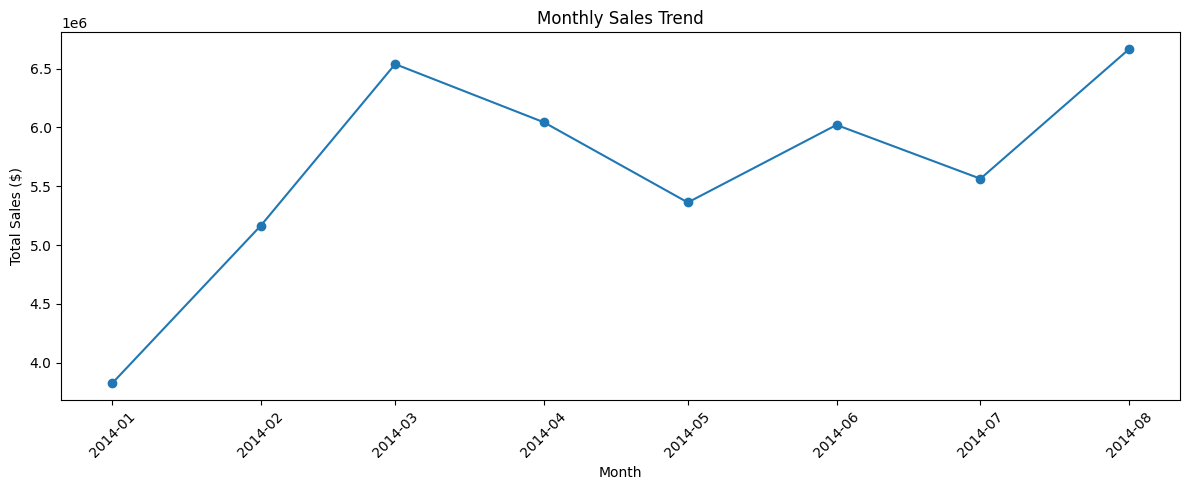

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Monthly Sales Trend
plt.figure(figsize=(12,5))
plt.plot(monthly['MonthID'], monthly['Total_Sales_Dollars'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Product Performance
Identifying top revenue-generating products.

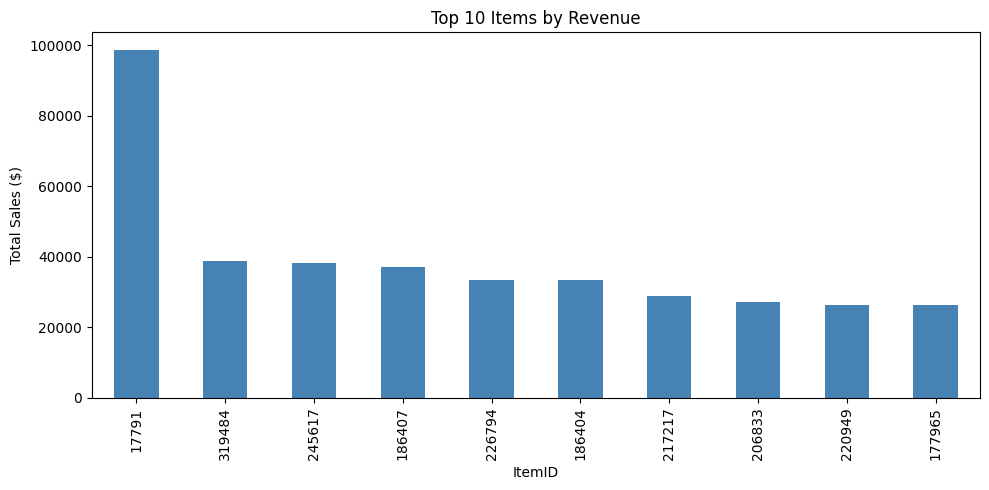

In [18]:
# 2. Top 10 Items by Revenue
plt.figure(figsize=(10,5))
top_items.plot(kind='bar', color='steelblue')
plt.title('Top 10 Items by Revenue')
plt.xlabel('ItemID')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

### 3.3 Location Performance
Ranking stores by total revenue and gross margin efficiency.

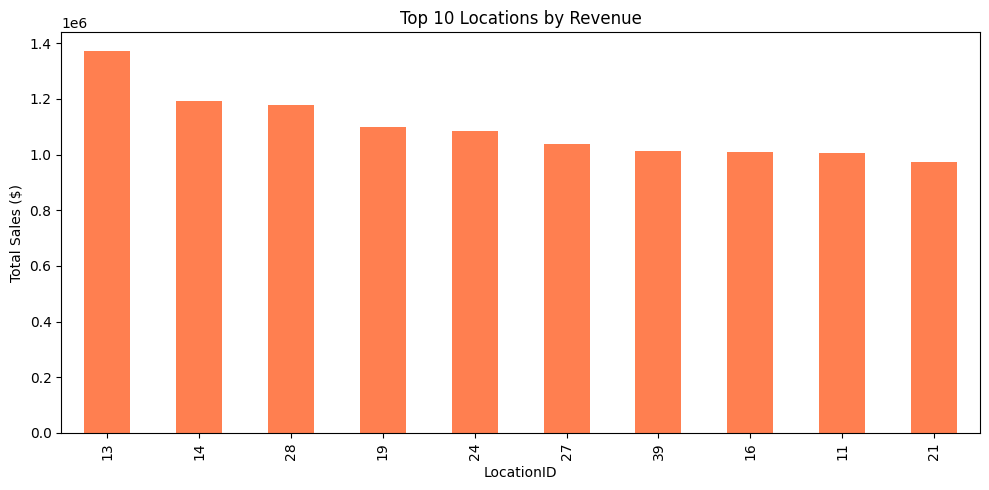

In [19]:
# 3. Top 10 Locations by Revenue
plt.figure(figsize=(10,5))
top_locations.plot(kind='bar', color='coral')
plt.title('Top 10 Locations by Revenue')
plt.xlabel('LocationID')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

### 3.4 Markdown Impact Analysis
Examining the relationship between markdown and regular sales channels.

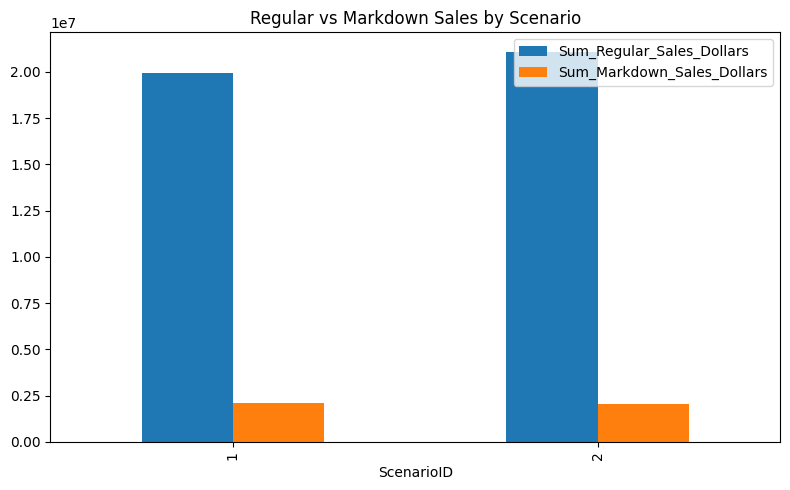

In [20]:
# 4. Regular vs Markdown Sales
scenario_sales = df.groupby('ScenarioID')[['Sum_Regular_Sales_Dollars','Sum_Markdown_Sales_Dollars']].sum()
scenario_sales.plot(kind='bar', figsize=(8,5))
plt.title('Regular vs Markdown Sales by Scenario')
plt.tight_layout()
plt.show()

## 4. Key Business Insights

1. **Seasonality:** Sales peak in August ($6.67M) and dip in January ($3.82M) — 
   promotions should be planned ahead of the January dip.
2. **Star Product:** Item 17791 generates $98,697 — 2.5x more than the next best item.
3. **Top Location:** Location 13 leads with $1.37M in revenue and strong margin.
4. **Margin Health:** Overall gross margin is 41.98% — consistent across all 100 locations.
5. **Markdown Efficiency:** Markdown sales are less than 10% of total revenue — 
   business is not discount-dependent.
6. **Scenario Parity:** Actual vs Plan variance is minimal ($22M vs $23.1M).

In [21]:
# Yearly sales comparison
yearly = df.groupby('Year')['Total_Sales_Dollars'].sum()
print(yearly)

Year
2014    45184553.69
Name: Total_Sales_Dollars, dtype: float64


In [22]:
# Gross margin % by location
loc_summary = df.groupby('LocationID').agg(
    Total_Sales=('Total_Sales_Dollars','sum'),
    Total_Margin=('Sum_GrossMarginAmount','sum')
).reset_index()
loc_summary['Margin_Pct'] = (loc_summary['Total_Margin'] / loc_summary['Total_Sales']) * 100
print(loc_summary.sort_values('Margin_Pct', ascending=False).head(10))

    LocationID  Total_Sales  Total_Margin  Margin_Pct
55         526    300005.86     140479.08   46.825445
41         507    339273.41     157737.33   46.492689
39         504    377798.57     174806.28   46.269704
48         518    292446.93     133538.48   45.662466
74         549    212133.19      95656.75   45.092779
70         545    185226.22      83386.19   45.018567
71         546    233176.26     104847.19   44.964779
63         537    255099.12     114423.79   44.854639
95         579    227014.07     101754.94   44.823187
50         520    280737.43     125788.61   44.806498


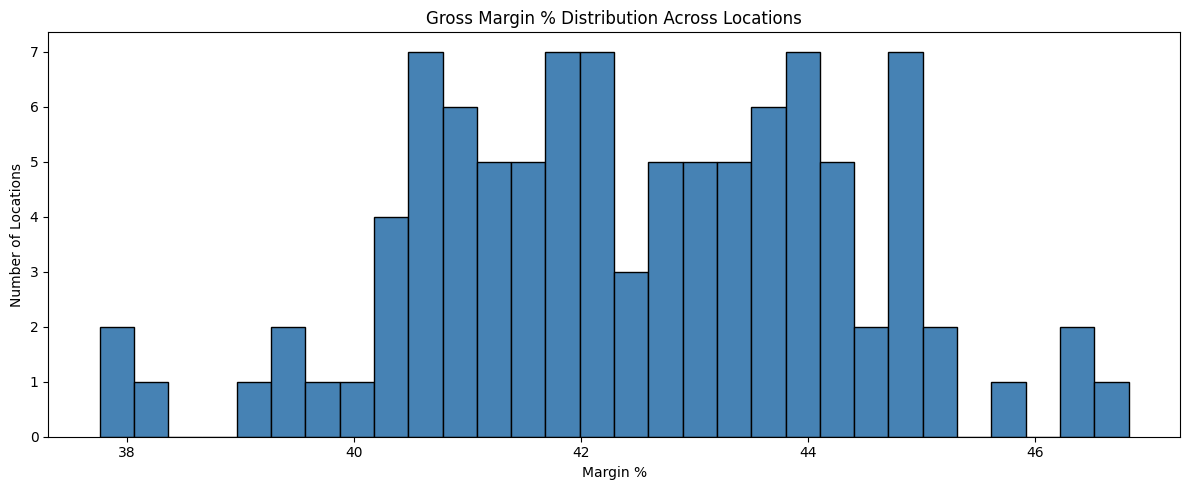

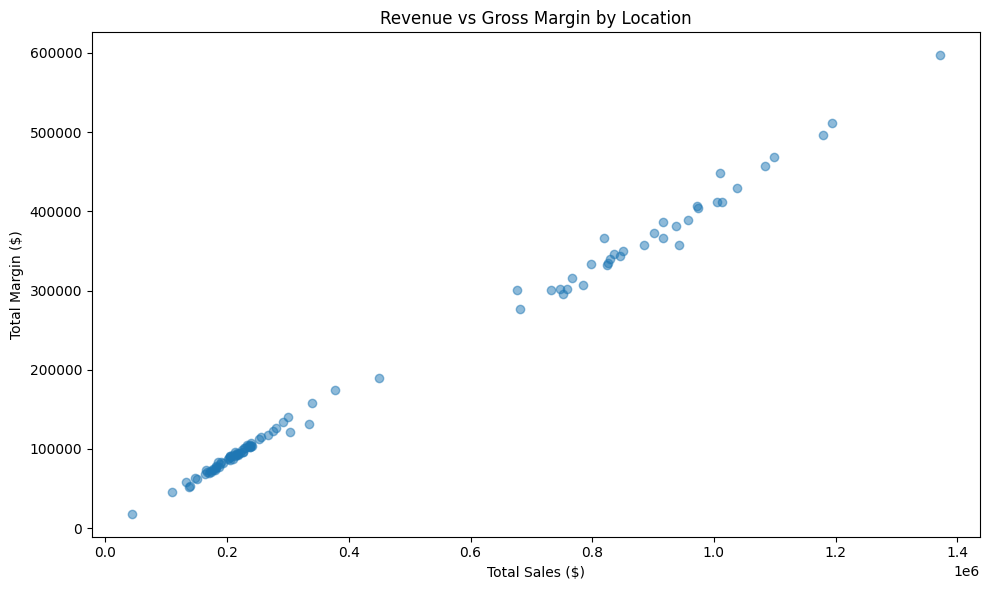

In [23]:
# Margin % distribution across all locations
plt.figure(figsize=(12,5))
plt.hist(loc_summary['Margin_Pct'], bins=30, color='steelblue', edgecolor='black')
plt.title('Gross Margin % Distribution Across Locations')
plt.xlabel('Margin %')
plt.ylabel('Number of Locations')
plt.tight_layout()
plt.show()

# Revenue vs Margin scatter
plt.figure(figsize=(10,6))
plt.scatter(loc_summary['Total_Sales'], loc_summary['Total_Margin'], alpha=0.5)
plt.title('Revenue vs Gross Margin by Location')
plt.xlabel('Total Sales ($)')
plt.ylabel('Total Margin ($)')
plt.tight_layout()
plt.show()

In [24]:
# Summary stats for your report
print("=== RETAIL SALES ANALYSIS SUMMARY ===")
print(f"Total Revenue (2014): ${df['Total_Sales_Dollars'].sum():,.2f}")
print(f"Total Gross Margin: ${df['Sum_GrossMarginAmount'].sum():,.2f}")
print(f"Overall Margin %: {(df['Sum_GrossMarginAmount'].sum() / df['Total_Sales_Dollars'].sum()) * 100:.2f}%")
print(f"Total Locations: {df['LocationID'].nunique()}")
print(f"Total Products: {df['ItemID'].nunique()}")
print(f"Best Month: {monthly.loc[monthly['Total_Sales_Dollars'].idxmax(), 'MonthID']}")
print(f"Worst Month: {monthly.loc[monthly['Total_Sales_Dollars'].idxmin(), 'MonthID']}")
print(f"Top Item: {top_items.idxmax()} (${top_items.max():,.2f})")
print(f"Top Location: {top_locations.idxmax()} (${top_locations.max():,.2f})")

=== RETAIL SALES ANALYSIS SUMMARY ===
Total Revenue (2014): $45,184,553.69
Total Gross Margin: $18,968,753.26
Overall Margin %: 41.98%
Total Locations: 100
Total Products: 105916
Best Month: 2014-08-01 00:00:00
Worst Month: 2014-01-01 00:00:00
Top Item: 17791 ($98,697.63)
Top Location: 13 ($1,370,946.11)


## 5. Pareto Analysis — Product Revenue Concentration
Applying the 80/20 rule to identify which products drive the majority of revenue.

**Finding:** 23.1% of products (24,461 SKUs) generate 80% of total revenue.
Over 81,000 products contribute only 20% of revenue — candidates for range rationalization.

In [25]:
# Pareto Analysis — Items
item_sales = df.groupby('ItemID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).reset_index()
item_sales['Cumulative_Sales'] = item_sales['Total_Sales_Dollars'].cumsum()
item_sales['Cumulative_Pct'] = item_sales['Cumulative_Sales'] / item_sales['Total_Sales_Dollars'].sum() * 100
item_sales['Item_Pct'] = (item_sales.index + 1) / len(item_sales) * 100

In [26]:
# Find the 80% cutoff
cutoff = item_sales[item_sales['Cumulative_Pct'] <= 80]
print(f"Total items: {len(item_sales)}")
print(f"Items driving 80% of revenue: {len(cutoff)}")
print(f"That's {len(cutoff)/len(item_sales)*100:.1f}% of products driving 80% of revenue")
print(f"\nTop 10 items:\n{item_sales.head(10)}")

Total items: 105916
Items driving 80% of revenue: 24461
That's 23.1% of products driving 80% of revenue

Top 10 items:
   ItemID  Total_Sales_Dollars  Cumulative_Sales  Cumulative_Pct  Item_Pct
0   17791             98697.63          98697.63        0.218432  0.000944
1  319484             38754.60         137452.23        0.304202  0.001888
2  245617             38221.96         175674.19        0.388793  0.002832
3  186407             36986.52         212660.71        0.470649  0.003777
4  226794             33526.44         246187.15        0.544848  0.004721
5  186404             33486.25         279673.40        0.618958  0.005665
6  217217             28850.28         308523.68        0.682808  0.006609
7  206833             27245.45         335769.13        0.743106  0.007553
8  220949             26292.64         362061.77        0.801295  0.008497
9  177965             26223.79         388285.56        0.859333  0.009441


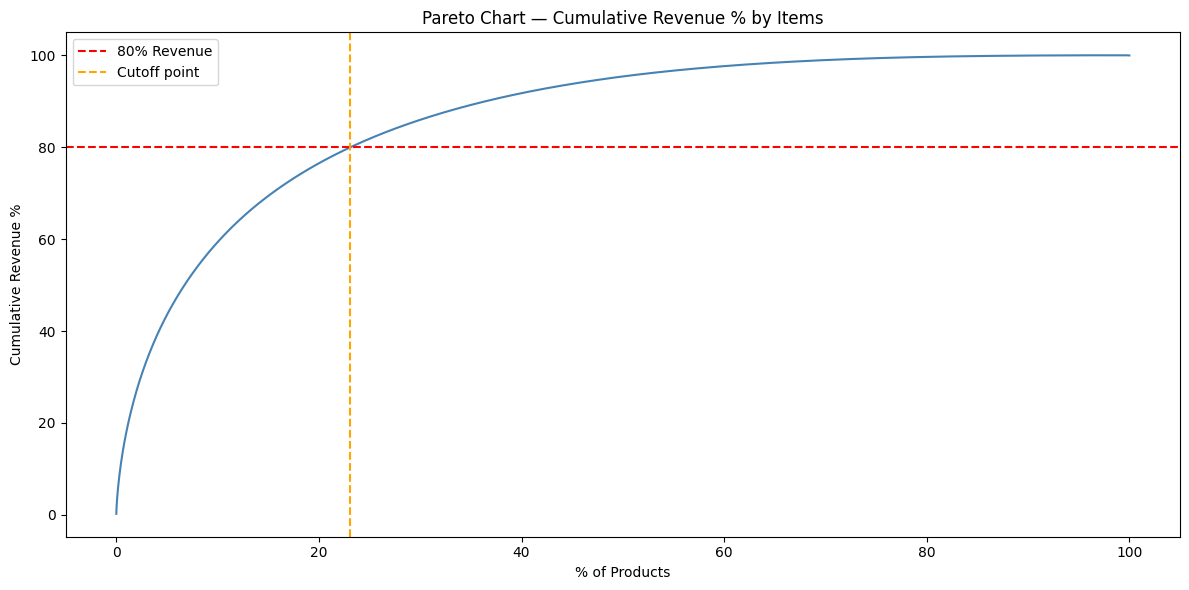

In [27]:
plt.figure(figsize=(12,6))
plt.plot(item_sales['Item_Pct'], item_sales['Cumulative_Pct'], color='steelblue')
plt.axhline(y=80, color='red', linestyle='--', label='80% Revenue')
plt.axvline(x=item_sales[item_sales['Cumulative_Pct'] <= 80]['Item_Pct'].max(), 
            color='orange', linestyle='--', label='Cutoff point')
plt.title('Pareto Chart — Cumulative Revenue % by Items')
plt.xlabel('% of Products')
plt.ylabel('Cumulative Revenue %')
plt.legend()
plt.tight_layout()
plt.show()

## Pareto — Locations
**Finding:** 52 out of 100 locations drive 80% of revenue.
Unlike products, stores show no heavy concentration — revenue is evenly distributed.
The inefficiency in this business lies in the product portfolio, not the store network.
Action: Focus range rationalization on low-performing SKUs, not store closures.

In [28]:
# Pareto Analysis — Locations
loc_sales = df.groupby('LocationID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).reset_index()
loc_sales['Cumulative_Sales'] = loc_sales['Total_Sales_Dollars'].cumsum()
loc_sales['Cumulative_Pct'] = loc_sales['Cumulative_Sales'] / loc_sales['Total_Sales_Dollars'].sum() * 100
loc_sales['Loc_Pct'] = (loc_sales.index + 1) / len(loc_sales) * 100

cutoff_loc = loc_sales[loc_sales['Cumulative_Pct'] <= 80]
print(f"Total locations: {len(loc_sales)}")
print(f"Locations driving 80% of revenue: {len(cutoff_loc)}")
print(f"That's {len(cutoff_loc)/len(loc_sales)*100:.1f}% of locations driving 80% of revenue")

Total locations: 100
Locations driving 80% of revenue: 52
That's 52.0% of locations driving 80% of revenue


## 6. Interactive Visualizations (Plotly)
Upgrading static charts to interactive visuals — hover, zoom, and filter enabled.
Charts include monthly trend, top 20 items, revenue vs margin scatter, and Pareto chart.

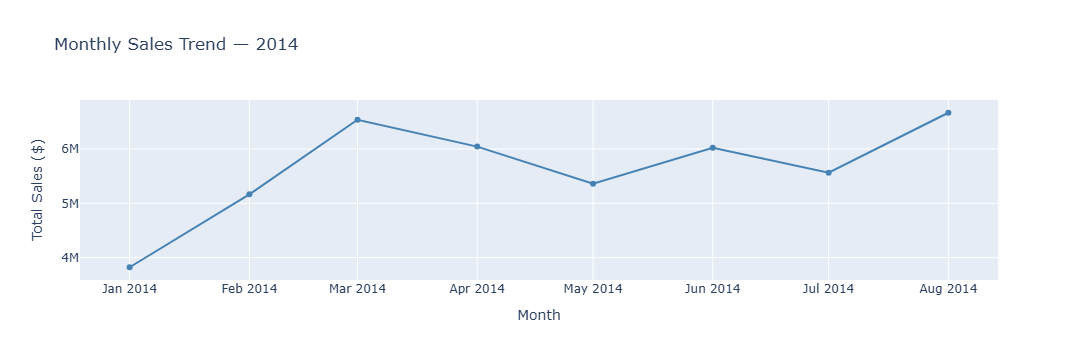

In [30]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.line(monthly, x='MonthID', y='Total_Sales_Dollars',
              title='Monthly Sales Trend — 2014',
              markers=True,
              labels={'Total_Sales_Dollars': 'Total Sales ($)', 'MonthID': 'Month'})
fig.update_traces(line_color='steelblue', line_width=2)
fig.show()

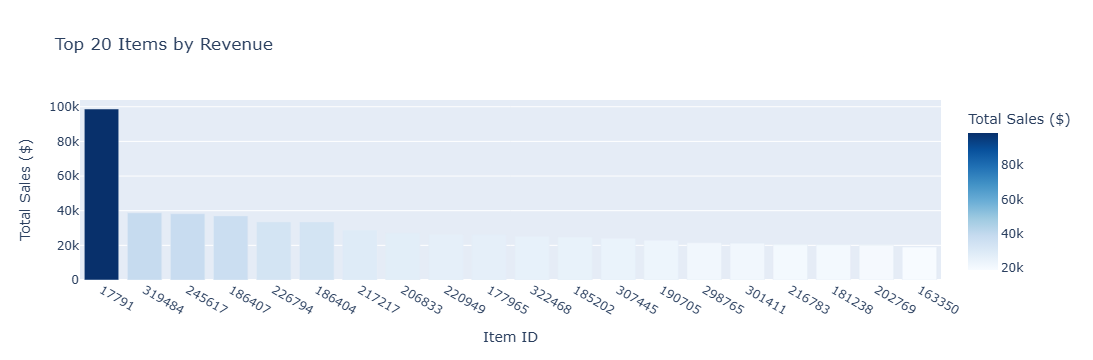

In [33]:
top20 = df.groupby('ItemID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).head(20).reset_index()
top20['ItemID'] = top20['ItemID'].astype(str)  # fix

fig = px.bar(top20, x='ItemID', y='Total_Sales_Dollars',
             title='Top 20 Items by Revenue',
             labels={'Total_Sales_Dollars': 'Total Sales ($)', 'ItemID': 'Item ID'},
             color='Total_Sales_Dollars',
             color_continuous_scale='Blues')
fig.show()

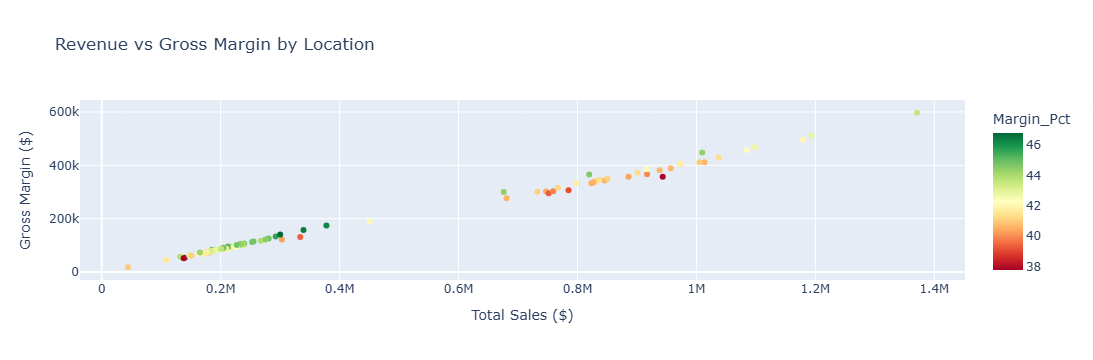

In [32]:
fig = px.scatter(loc_summary, x='Total_Sales', y='Total_Margin',
                 hover_data=['LocationID', 'Margin_Pct'],
                 title='Revenue vs Gross Margin by Location',
                 labels={'Total_Sales': 'Total Sales ($)', 'Total_Margin': 'Gross Margin ($)'},
                 color='Margin_Pct',
                 color_continuous_scale='RdYlGn')
fig.show()

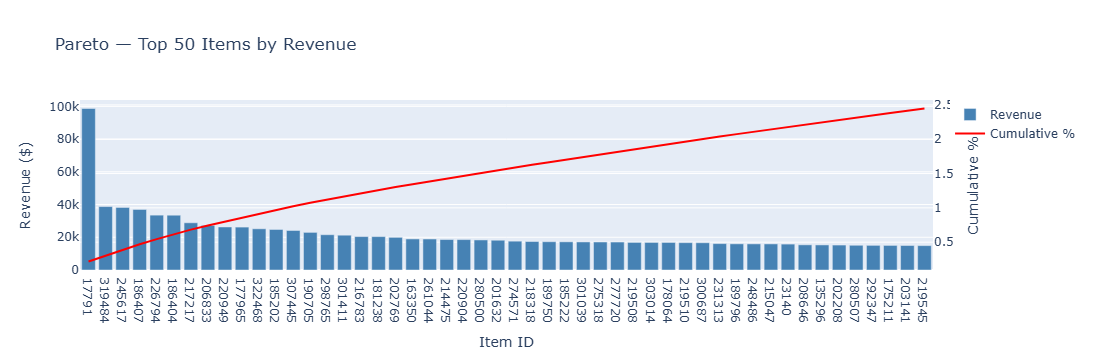

In [34]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=item_sales.head(50)['ItemID'].astype(str),
    y=item_sales.head(50)['Total_Sales_Dollars'],
    name='Revenue',
    marker_color='steelblue'
))

fig.add_trace(go.Scatter(
    x=item_sales.head(50)['ItemID'].astype(str),
    y=item_sales.head(50)['Cumulative_Pct'],
    name='Cumulative %',
    yaxis='y2',
    line=dict(color='red', width=2)
))

fig.update_layout(
    title='Pareto — Top 50 Items by Revenue',
    yaxis=dict(title='Revenue ($)'),
    yaxis2=dict(title='Cumulative %', overlaying='y', side='right'),
    xaxis=dict(title='Item ID')
)
fig.show()

## 7. Sales Forecasting — Prophet
Forecasting next 6 months using Meta's Prophet library.

**Limitation:** Dataset contains only 8 months of data (Jan–Aug 2014). 
Prophet requires 2+ years to detect seasonality reliably.
The upward trend forecast should be treated as directional only, not precise.
For production forecasting, multi-year historical data is required.

**Forecast:** Sales projected to grow from $6.7M (Sep) to $7.9M (Feb 2015).

12:09:42 - cmdstanpy - INFO - Chain [1] start processing
12:09:42 - cmdstanpy - INFO - Chain [1] done processing


Text(0.5, 0.98, 'Forecast Components')

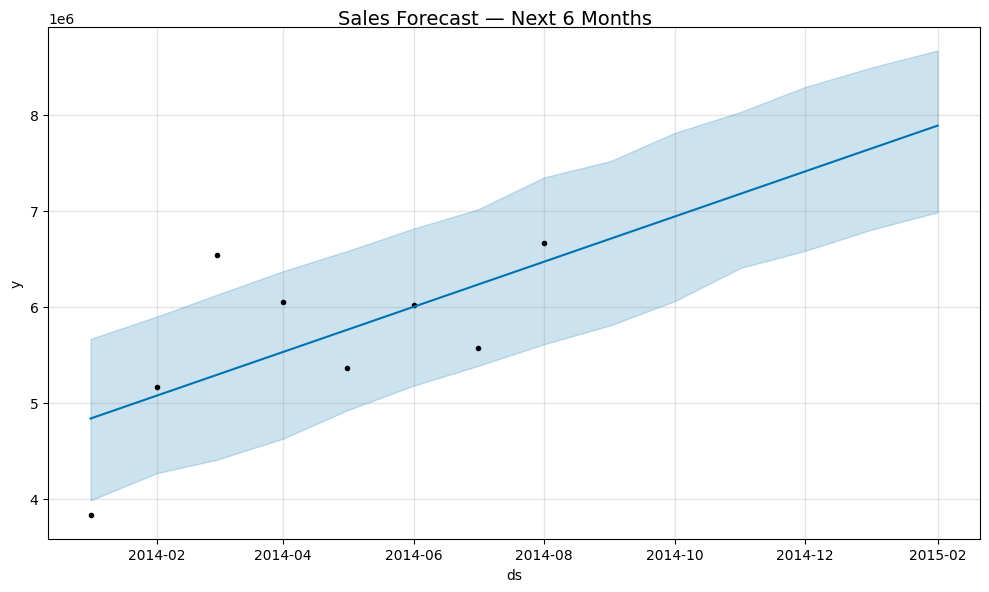

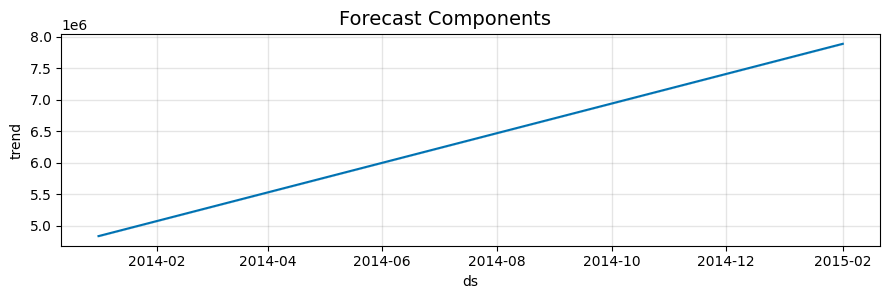

In [36]:
from prophet import Prophet
import pandas as pd

# Prepare data for Prophet — requires columns 'ds' (date) and 'y' (value)
prophet_df = monthly[['MonthID', 'Total_Sales_Dollars']].rename(
    columns={'MonthID': 'ds', 'Total_Sales_Dollars': 'y'}
)

# Build and fit the model
model = Prophet(seasonality_mode='multiplicative')
model.fit(prophet_df)

# Forecast 6 months ahead
future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

# Plot
fig1 = model.plot(forecast)
fig1.suptitle('Sales Forecast — Next 6 Months', fontsize=14)

fig2 = model.plot_components(forecast)
fig2.suptitle('Forecast Components', fontsize=14)

In [37]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))

           ds          yhat    yhat_lower    yhat_upper
8  2014-09-01  6.705981e+06  5.804005e+06  7.515132e+06
9  2014-10-01  6.937122e+06  6.054956e+06  7.808154e+06
10 2014-11-01  7.175967e+06  6.402701e+06  8.027647e+06
11 2014-12-01  7.407108e+06  6.579484e+06  8.286436e+06
12 2015-01-01  7.645954e+06  6.799888e+06  8.489399e+06
13 2015-02-01  7.884799e+06  6.981623e+06  8.667734e+06


## 8. K-Means Clustering — Store Segmentation
Grouping 100 locations into 3 behavioral clusters using Sales, Margin %, Markdown %, and Units.

- **Cluster 0 (High Volume):** 41.2% margin — large revenue, average efficiency
- **Cluster 1 (Weak Stores):** 41.2% margin, 13.2% markdown — smallest and most discount-dependent
- **Cluster 2 (Efficient Stores):** 43.9% margin — best unit economics, growth candidates

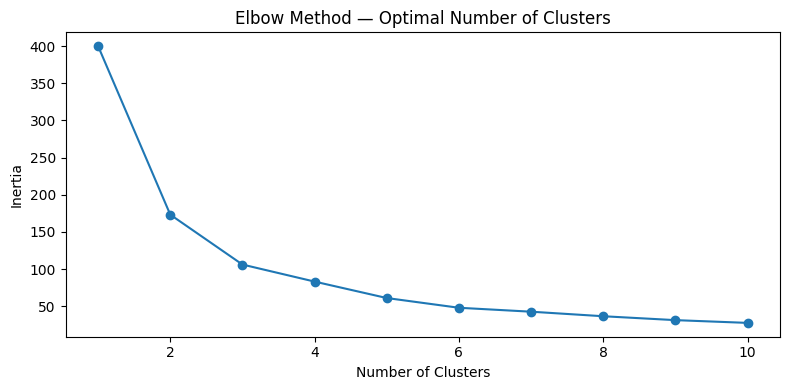

In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Build location-level feature set
cluster_df = df.groupby('LocationID').agg(
    Total_Sales=('Total_Sales_Dollars', 'sum'),
    Total_Margin=('Sum_GrossMarginAmount', 'sum'),
    Total_Units=('Total_Sales_Units', 'sum'),
    Markdown_Sales=('Sum_Markdown_Sales_Dollars', 'sum')
).reset_index()

cluster_df['Margin_Pct'] = (cluster_df['Total_Margin'] / cluster_df['Total_Sales']) * 100
cluster_df['Markdown_Pct'] = (cluster_df['Markdown_Sales'] / cluster_df['Total_Sales']) * 100

# Scale the features
features = ['Total_Sales', 'Margin_Pct', 'Markdown_Pct', 'Total_Units']
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_df[features])

# Find optimal clusters using elbow method
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

           Total_Sales  Margin_Pct  Markdown_Pct    Total_Units
Cluster                                                        
0        916595.862727   41.216628      8.789781  188398.939394
1        172983.683810   41.203462     13.198730   27211.809524
2        245744.192609   43.925400      9.786360   36696.304348


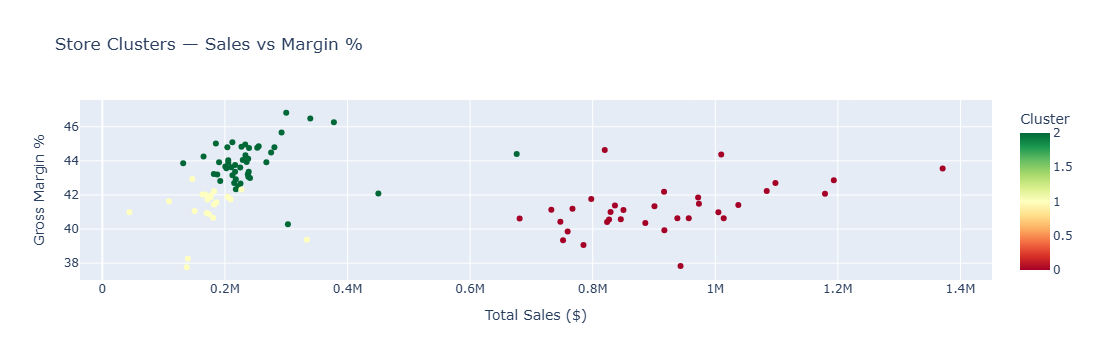

In [40]:
# Apply K-Means with 3 clusters
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['Cluster'] = km_final.fit_predict(scaled)

# See what each cluster looks like
print(cluster_df.groupby('Cluster')[features].mean())

# Visualize
fig = px.scatter(cluster_df, x='Total_Sales', y='Margin_Pct',
                 color='Cluster', hover_data=['LocationID'],
                 title='Store Clusters — Sales vs Margin %',
                 labels={'Total_Sales': 'Total Sales ($)', 'Margin_Pct': 'Gross Margin %'},
                 color_continuous_scale='RdYlGn')
fig.show()

## 9. Sales Regression Model
Predicting store-level revenue using Linear Regression.

- **R² Score:** 0.9969 — model explains 99.7% of sales variance
- **MAE:** $15,605 — average prediction error across test stores
- **Key driver:** Total units sold is the strongest predictor of revenue
- **Note:** High R² reflects the mathematical relationship between units and revenue.
  Production models would incorporate external variables for more actionable predictions.

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
X = cluster_df[['Margin_Pct', 'Markdown_Pct', 'Total_Units']]
y = cluster_df['Total_Sales']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Evaluate
y_pred = model_lr.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):,.2f}")

# Coefficients
for feature, coef in zip(X.columns, model_lr.coef_):
    print(f"{feature}: {coef:.4f}")

R² Score: 0.9969
Mean Absolute Error: $15,605.67
Margin_Pct: 20871.8565
Markdown_Pct: 5615.7600
Total_Units: 4.8060


## Dashboard Preview
![Sales Overview](dashboard_screenshots/Sales.png)

[View Full Interactive Dashboard] https://app.fabric.microsoft.com/links/bK5vnopljF?ctid=56c1d497-700b-49cf-8f8d-3dd6b20d522f&pbi_source=linkShare